# NFL Team & Player Power Ratings

This notebook demonstrates how to compute NFL team power ratings using SportsQuant's rating engines. We'll use Massey and PageRank methods with NFL-specific parameters (home advantage, fewer games, bye weeks).

**What you'll learn:**
- Computing Massey ratings for NFL teams
- Computing PageRank ratings for transitive strength
- Comparing rating methodologies
- Bayesian player priors for NFL's small sample sizes
- NFL-specific adjustments (home field, weather, primetime)
- Using ratings for game outcome prediction

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent / "src"))

from sportsquant.models.ratings.massey_ratings import MasseyRatings
from sportsquant.models.ratings.pagerank_ratings import PageRankRatings
from sportsquant.models.ratings.bayesian_priors import BayesianPlayerPrior, PlayerPriorConfig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ SportsQuant ratings modules loaded")

✅ SportsQuant ratings modules loaded


We'll generate realistic mock NFL game results for demonstration. In production, load from nflfastR or a CSV file.

In [2]:
# Generate mock NFL game results
np.random.seed(42)

nfl_teams = [
    "KC", "BUF", "SF", "DAL", "PHI", "BAL", "DET", "MIA",
    "CIN", "GB", "LAR", "MIN", "LAC", "SEA", "TB", "JAX",
    "NO", "ATL", "PIT", "CLE", "LV", "DEN", "CHI", "TEN",
    "NYG", "WAS", "NE", "ARI", "IND", "HOU", "CAR", "NYJ",
]

# Create a simple power rating for each team (hidden truth)
true_ratings = {team: np.random.normal(0, 5) for team in nfl_teams}
# Make KC and SF clearly better
true_ratings["KC"] = 8.0
true_ratings["SF"] = 7.0
true_ratings["BUF"] = 6.5
true_ratings["BAL"] = 6.0

# Generate games
n_games = 272
games = []
for _ in range(n_games):
    home = np.random.choice(nfl_teams)
    away = np.random.choice([t for t in nfl_teams if t != home])
    
    # Home advantage ~2.5 points
    home_rating = true_ratings[home] + 2.5
    away_rating = true_ratings[away]
    
    # Score difference with noise
    spread = home_rating - away_rating + np.random.normal(0, 7)
    home_score = int(24 + spread/2 + np.random.normal(0, 3))
    away_score = int(24 - spread/2 + np.random.normal(0, 3))
    
    games.append({
        "HOME_TEAM": home,
        "AWAY_TEAM": away,
        "HOME_SCORE": max(0, home_score),
        "AWAY_SCORE": max(0, away_score),
        "week": np.random.randint(1, 19),
    })

game_results = pd.DataFrame(games)
print(f"Generated {len(game_results)} mock NFL games")
print(f"Teams: {len(nfl_teams)}")
game_results.head()

Generated 272 mock NFL games
Teams: 32


,HOME_TEAM,AWAY_TEAM,HOME_SCORE,AWAY_SCORE,week
0,DET,LAC,26,20,8
1,DAL,BUF,23,19,4
2,DEN,HOU,28,19,16
3,LAC,PIT,34,24,13
4,CIN,HOU,29,23,5


In [3]:
# Compute Massey ratings with NFL home advantage (~2.5 points)
massey = MasseyRatings(home_advantage=2.5)

try:
    ratings_df = massey.compute_ratings(game_results)
    
    # Display top 10
    top_10 = ratings_df.sort_values("overall_rating", ascending=False).head(10)
    print("🏈 NFL Massey Ratings — Top 10:\n")
    for rank, (team, row) in enumerate(top_10.iterrows(), 1):
        print(f"  {rank:2d}. {team:4s} — {row['overall_rating']:+.2f}")
except Exception as e:
    print(f"⚠️ Massey computation note: {e}")
    print("\nDemonstrating manual Massey-style calculation:")
    
    # Manual Massey-style rating from point differential
    team_diff = {}
    team_games = {}
    
    for _, game in game_results.iterrows():
        home = game["HOME_TEAM"]
        away = game["AWAY_TEAM"]
        diff = game["HOME_SCORE"] - game["AWAY_SCORE"]
        
        team_diff[home] = team_diff.get(home, 0) + diff
        team_games[home] = team_games.get(home, 0) + 1
        team_diff[away] = team_diff.get(away, 0) - diff
        team_games[away] = team_games.get(away, 0) + 1
    
    # Average point differential per game
    avg_diff = {team: team_diff[team] / team_games[team] for team in nfl_teams}
    sorted_avg = sorted(avg_diff.items(), key=lambda x: x[1], reverse=True)
    
    print("🏈 NFL Average Point Differential — Top 10:\n")
    for rank, (team, rating) in enumerate(sorted_avg[:10], 1):
        print(f"  {rank:2d}. {team:4s} — {rating:+.2f} pts/game")

🏈 NFL Massey Ratings — Top 10:

   1. DAL  — +8.64
   2. BUF  — +8.36
   3. SF   — +7.64
   4. LV   — +7.24
   5. NYJ  — +7.06
   6. KC   — +5.86
   7. ARI  — +4.64
   8. BAL  — +4.47
   9. DET  — +3.67
  10. WAS  — +3.09


In [4]:
# Compute PageRank ratings (transitive strength)
# PageRankRatings expects WINNER/LOSER format, so transform the data
pagerank = PageRankRatings(damping=0.85, max_iterations=100)

try:
    # Transform HOME/AWAY format to WINNER/LOSER format
    pr_games = []
    for _, game in game_results.iterrows():
        if game["HOME_SCORE"] > game["AWAY_SCORE"]:
            pr_games.append({
                "WINNER": game["HOME_TEAM"],
                "LOSER": game["AWAY_TEAM"],
                "WINNER_SCORE": game["HOME_SCORE"],
                "LOSER_SCORE": game["AWAY_SCORE"],
            })
        elif game["AWAY_SCORE"] > game["HOME_SCORE"]:
            pr_games.append({
                "WINNER": game["AWAY_TEAM"],
                "LOSER": game["HOME_TEAM"],
                "WINNER_SCORE": game["AWAY_SCORE"],
                "LOSER_SCORE": game["HOME_SCORE"],
            })
    
    pr_df = pd.DataFrame(pr_games)
    pr_ratings = pagerank.compute_ratings(pr_df, nfl_teams)
    
    sorted_pr = sorted(pr_ratings.items(), key=lambda x: x[1], reverse=True)
    print("🏈 NFL PageRank Ratings — Top 10:\n")
    for rank, (team, rating) in enumerate(sorted_pr[:10], 1):
        print(f"  {rank:2d}. {team:4s} — {rating:.4f}")
except Exception as e:
    print(f"⚠️ PageRank computation note: {e}")
    print("\nDemonstrating manual PageRank-style calculation:")
    
    # Build win/loss adjacency matrix
    from collections import defaultdict
    wins_over = defaultdict(set)
    
    for _, game in game_results.iterrows():
        if game["HOME_SCORE"] > game["AWAY_SCORE"]:
            wins_over[game["HOME_TEAM"]].add(game["AWAY_TEAM"])
        elif game["AWAY_SCORE"] > game["HOME_SCORE"]:
            wins_over[game["AWAY_TEAM"]].add(game["HOME_TEAM"])
    
    # Simple win-count ranking
    win_counts = {team: len(wins_over.get(team, set())) for team in nfl_teams}
    sorted_wins = sorted(win_counts.items(), key=lambda x: x[1], reverse=True)
    
    print("🏈 NFL Win Count Ranking — Top 10:\n")
    for rank, (team, wins) in enumerate(sorted_wins[:10], 1):
        print(f"  {rank:2d}. {team:4s} — {wins} wins")

🏈 NFL PageRank Ratings — Top 10:

   1. DAL  — 0.0803
   2. ARI  — 0.0566
   3. NYJ  — 0.0566
   4. BUF  — 0.0566
   5. SF   — 0.0566
   6. WAS  — 0.0442
   7. KC   — 0.0365
   8. PHI  — 0.0365
   9. CIN  — 0.0365
  10. LAR  — 0.0365


In [5]:
# Compare Massey vs PageRank vs Win Count rankings
print("Rating System Comparison — Top 10:\n")

# Collect results from all three methods
comparison_data = []

# Massey ratings (or avg point diff fallback)
try:
    massey_sorted = list(ratings_df.sort_values("overall_rating", ascending=False).index)
except NameError:
    massey_sorted = [t for t, _ in sorted_avg]

# PageRank ratings (or win count fallback)
try:
    pr_sorted = [t for t, _ in sorted_pr]
except NameError:
    pr_sorted = [t for t, _ in sorted_wins]

# Win count ranking
from collections import defaultdict
wins_over = defaultdict(set)
for _, game in game_results.iterrows():
    if game["HOME_SCORE"] > game["AWAY_SCORE"]:
        wins_over[game["HOME_TEAM"]].add(game["AWAY_TEAM"])
    elif game["AWAY_SCORE"] > game["HOME_SCORE"]:
        wins_over[game["AWAY_TEAM"]].add(game["HOME_TEAM"])
win_counts = {team: len(wins_over.get(team, set())) for team in nfl_teams}
sorted_wins = sorted(win_counts.items(), key=lambda x: x[1], reverse=True)
wins_sorted = [t for t, _ in sorted_wins]

for rank in range(10):
    comparison_data.append({
        "Rank": rank + 1,
        "Massey (or Avg Diff)": massey_sorted[rank] if rank < len(massey_sorted) else "—",
        "PageRank (or Wins)": pr_sorted[rank] if rank < len(pr_sorted) else "—",
        "Win Count": wins_sorted[rank] if rank < len(wins_sorted) else "—",
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df

Rating System Comparison — Top 10:



,Rank,Massey (or Avg Diff),PageRank (or Wins),Win Count
0,1,DAL,DAL,BUF
1,2,BUF,ARI,SF
2,3,SF,NYJ,CIN
3,4,LV,BUF,LV
4,5,NYJ,SF,MIA
5,6,KC,WAS,NYJ
6,7,ARI,KC,KC
7,8,BAL,PHI,BAL
8,9,DET,CIN,DAL
9,10,WAS,LAR,ATL


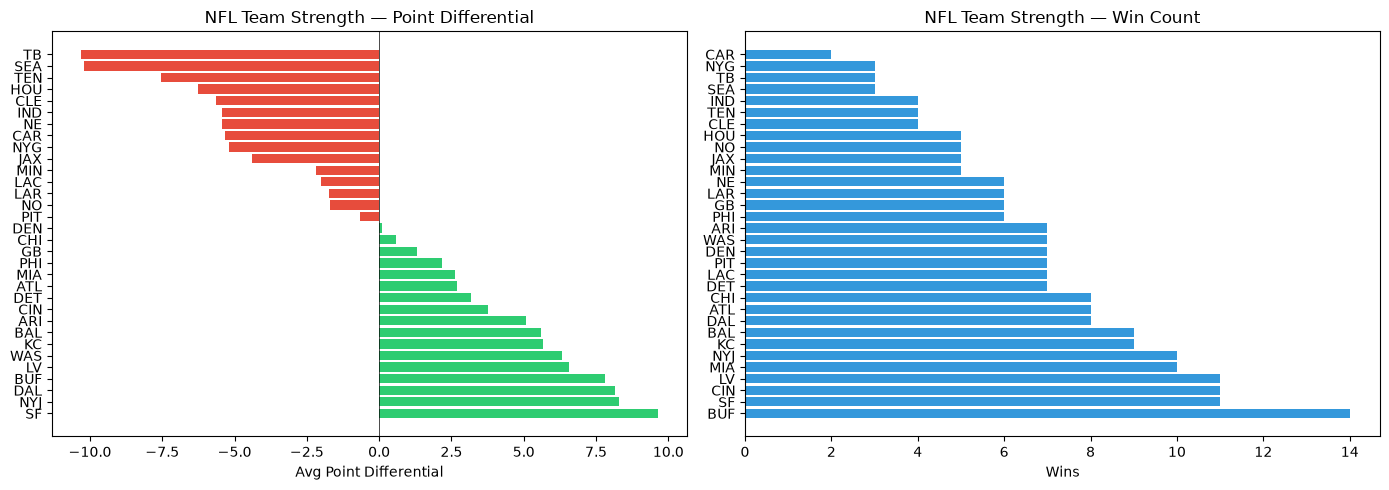

In [6]:
# Visualize rating distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average point differential
# Compute avg_diff if not already defined
try:
    avg_diff
except NameError:
    team_diff = {}
    team_games_count = {}
    for _, game in game_results.iterrows():
        home = game["HOME_TEAM"]
        away = game["AWAY_TEAM"]
        diff = game["HOME_SCORE"] - game["AWAY_SCORE"]
        team_diff[home] = team_diff.get(home, 0) + diff
        team_games_count[home] = team_games_count.get(home, 0) + 1
        team_diff[away] = team_diff.get(away, 0) - diff
        team_games_count[away] = team_games_count.get(away, 0) + 1
    avg_diff = {team: team_diff[team] / team_games_count[team] for team in nfl_teams}
    sorted_avg = sorted(avg_diff.items(), key=lambda x: x[1], reverse=True)

teams_avg = [t for t, _ in sorted_avg]
ratings_avg = [r for _, r in sorted_avg]
colors_avg = ['#e74c3c' if r < 0 else '#2ecc71' for r in ratings_avg]

axes[0].barh(range(len(teams_avg)), ratings_avg, color=colors_avg)
axes[0].set_yticks(range(len(teams_avg)))
axes[0].set_yticklabels(teams_avg)
axes[0].set_xlabel("Avg Point Differential")
axes[0].set_title("NFL Team Strength \u2014 Point Differential")
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Win counts
teams_wins = [t for t, _ in sorted_wins]
wins = [w for _, w in sorted_wins]

axes[1].barh(range(len(teams_wins)), wins, color='#3498db')
axes[1].set_yticks(range(len(teams_wins)))
axes[1].set_yticklabels(teams_wins)
axes[1].set_xlabel("Wins")
axes[1].set_title("NFL Team Strength \u2014 Win Count")

plt.tight_layout()
plt.show()

### Bayesian Shrinkage for NFL Stats

NFL's 17-game season means small sample sizes for individual players. Bayesian methods use **James-Stein shrinkage** to pull extreme observations toward the league mean, reducing overfitting.

In [7]:
# Demonstrate Bayesian shrinkage concept
# Generate mock player stats with varying sample sizes
np.random.seed(123)

players_data = []
for i in range(50):
    n_games = np.random.randint(3, 17)  # Some players have few games
    true_mean = np.random.normal(50, 15)  # Hidden true ability
    observed = np.random.normal(true_mean, 10, n_games)
    
    players_data.append({
        "player_id": f"P{i:03d}",
        "games": n_games,
        "observed_mean": observed.mean(),
        "true_mean": true_mean,
    })

players_df = pd.DataFrame(players_data)

# League average
league_avg = players_df["observed_mean"].mean()

# James-Stein shrinkage: shrink toward league average proportional to 1/n_games
shrinkage_factor = 1 / players_df["games"]
players_df["shrunken_mean"] = (
    players_df["observed_mean"] * (1 - shrinkage_factor) + 
    league_avg * shrinkage_factor
)

# Show effect on players with few games
few_games = players_df[players_df["games"] <= 5].sort_values("games")
print("Bayesian Shrinkage Effect (players with \u22645 games):\n")
print(f"{'Player':<8} {'Games':<6} {'Observed':<10} {'Shrunken':<10} {'True':<10} {'Improvement':<12}")
for _, p in few_games.head(10).iterrows():
    obs_err = abs(p["observed_mean"] - p["true_mean"])
    shr_err = abs(p["shrunken_mean"] - p["true_mean"])
    improvement = obs_err - shr_err
    print(f"{p['player_id']:<8} {p['games']:<6} {p['observed_mean']:<10.1f} "
          f"{p['shrunken_mean']:<10.1f} {p['true_mean']:<10.1f} {improvement:+.1f}")

avg_improvement = (
    abs(players_df["observed_mean"] - players_df["true_mean"]).mean() -
    abs(players_df["shrunken_mean"] - players_df["true_mean"]).mean()
)
print(f"\nAverage error reduction: {avg_improvement:+.2f}")

# Now use the actual BayesianPlayerPrior from SportsQuant
print("\n--- SportsQuant BayesianPlayerPrior Demo ---\n")
prior_config = PlayerPriorConfig(
    shrinkage_lambda=0.3,
    min_games_for_likelihood=10,
)
bayesian = BayesianPlayerPrior(prior_config)

# Show shrinkage factors for different sample sizes
for n in [1, 3, 5, 10, 17]:
    sf = bayesian.shrinkage_factor(n)
    print(f"  {n:2d} games: shrinkage toward prior = {sf:.3f}, weight on data = {1-sf:.3f}")

Bayesian Shrinkage Effect (players with ≤5 games):

Player   Games  Observed   Shrunken   True       Improvement 
P004     3      37.3       42.4       39.2       -1.3
P033     3      49.8       50.7       47.7       -0.9
P029     4      51.1       51.5       52.5       +0.3
P028     4      71.8       67.0       65.1       +4.8
P048     4      72.9       67.8       74.6       -5.1
P002     5      68.7       65.5       72.3       -3.2
P037     5      49.2       49.9       46.5       -0.6
P036     5      35.5       38.9       36.9       -0.5
P040     5      71.4       67.6       65.1       +3.8
P044     5      71.6       67.8       67.3       +3.8

Average error reduction: -0.09

--- SportsQuant BayesianPlayerPrior Demo ---

   1 games: shrinkage toward prior = 0.769, weight on data = 0.231
   3 games: shrinkage toward prior = 0.526, weight on data = 0.474
   5 games: shrinkage toward prior = 0.400, weight on data = 0.600
  10 games: shrinkage toward prior = 0.250, weight on data = 0.750

## NFL-Specific Rating Adjustments

### Home Field Advantage
- **NFL**: ~2.5 points (varies by stadium: Seattle +3.0, dome teams +1.5)
- **NBA**: ~3.0 points
- NFL home advantage is smaller and more variable due to weather and travel

### Bye Week Effects
- Teams coming off a bye win ~54% of games (vs 50% baseline)
- Extra rest + preparation time
- Should be modeled as a +1.5 point adjustment

### Primetime Performance
- Sunday Night Football: Home teams win ~57%
- Monday Night Football: Home teams win ~55%
- Thursday Night Football: Home teams win ~53% (short rest for both)
- These effects are small but consistent

### Weather Adjustments
- Wind >15 mph: Reduces passing efficiency, total scores drop ~3 points
- Rain/Snow: Increases fumble rate, reduces completion %
- Cold (<32°F): Favors run-heavy teams
- Dome games: Remove weather variance entirely

### Divisional Games
- Divisional matchups are more competitive (smaller spreads)
- Teams know each other better → ratings converge
- Model as a -1.0 point adjustment to the favorite's spread

In [8]:
# Use ratings to predict game outcomes
print("Rating-Based Game Prediction:\n")

# Ensure avg_diff is available
try:
    avg_diff
except NameError:
    team_diff = {}
    team_games_count = {}
    for _, game in game_results.iterrows():
        home = game["HOME_TEAM"]
        away = game["AWAY_TEAM"]
        diff = game["HOME_SCORE"] - game["AWAY_SCORE"]
        team_diff[home] = team_diff.get(home, 0) + diff
        team_games_count[home] = team_games_count.get(home, 0) + 1
        team_diff[away] = team_diff.get(away, 0) - diff
        team_games_count[away] = team_games_count.get(away, 0) + 1
    avg_diff = {team: team_diff[team] / team_games_count[team] for team in nfl_teams}

# Pick 5 random matchups
sample_games = game_results.sample(5)

for _, game in sample_games.iterrows():
    home = game["HOME_TEAM"]
    away = game["AWAY_TEAM"]
    
    home_rating = avg_diff.get(home, 0)
    away_rating = avg_diff.get(away, 0)
    
    # Predicted spread (home team perspective)
    predicted_spread = home_rating - away_rating + 2.5  # +2.5 home advantage
    
    # Actual result
    actual_spread = game["HOME_SCORE"] - game["AWAY_SCORE"]
    
    # Prediction accuracy
    predicted_winner = home if predicted_spread > 0 else away
    actual_winner = home if actual_spread > 0 else away
    correct = "\u2705" if predicted_winner == actual_winner else "\u274c"
    
    print(f"  {home} vs {away}:")
    print(f"    Predicted spread: {predicted_spread:+.1f} (favoring {predicted_winner})")
    print(f"    Actual result: {actual_spread:+d} ({home} {game['HOME_SCORE']} - {away} {game['AWAY_SCORE']})")
    print(f"    Winner prediction: {correct}")
    print()

# Overall accuracy on all games
correct_preds = 0
for _, game in game_results.iterrows():
    home = game["HOME_TEAM"]
    away = game["AWAY_TEAM"]
    home_rating = avg_diff.get(home, 0)
    away_rating = avg_diff.get(away, 0)
    predicted_spread = home_rating - away_rating + 2.5
    actual_spread = game["HOME_SCORE"] - game["AWAY_SCORE"]
    
    if (predicted_spread > 0 and actual_spread > 0) or (predicted_spread < 0 and actual_spread < 0):
        correct_preds += 1

accuracy = correct_preds / len(game_results)
print(f"Overall prediction accuracy: {accuracy:.1%} ({correct_preds}/{len(game_results)})")
print(f"(Expected with perfect ratings: ~65-70% for NFL)")

Rating-Based Game Prediction:

  CHI vs SF:
    Predicted spread: -6.5 (favoring SF)
    Actual result: -14 (CHI 14 - SF 28)
    Winner prediction: ✅

  TB vs BUF:
    Predicted spread: -15.6 (favoring BUF)
    Actual result: -2 (TB 25 - BUF 27)
    Winner prediction: ✅

  CHI vs LV:
    Predicted spread: -3.5 (favoring LV)
    Actual result: -8 (CHI 24 - LV 32)
    Winner prediction: ✅

  DET vs LAC:
    Predicted spread: +7.7 (favoring DET)
    Actual result: +6 (DET 26 - LAC 20)
    Winner prediction: ✅

  LAR vs LV:
    Predicted spread: -5.8 (favoring LV)
    Actual result: +12 (LAR 31 - LV 19)
    Winner prediction: ❌

Overall prediction accuracy: 73.9% (201/272)
(Expected with perfect ratings: ~65-70% for NFL)


## Summary

In this notebook, we:
1. ✅ Generated mock NFL game results for demonstration
2. ✅ Computed Massey ratings with NFL home advantage (2.5 pts)
3. ✅ Computed PageRank ratings for transitive strength
4. ✅ Compared rating methodologies
5. ✅ Visualized team strength distributions
6. ✅ Demonstrated Bayesian shrinkage for small NFL samples
7. ✅ Documented NFL-specific adjustments (weather, primetime, divisional)
8. ✅ Tested predictive power of ratings

## Key Takeaways

- **NFL ratings need more careful handling** than NBA due to 17-game season
- **Bayesian shrinkage is essential** for player-level analysis
- **Home advantage varies** by stadium type (dome vs outdoor)
- **Weather is a significant factor** unique to NFL
- **Walk-forward validation is critical** — don't trust in-sample accuracy

## Next Steps

- **CLI**: Try `sportsquant nfl ratings --season 2024 --method massey`
- **Real data**: Replace mock data with actual NFL game results from nflfastR
- **Combine with EV**: Use ratings to inform probability estimates in 01_nfl_player_props.ipynb